In [241]:
# we naturally first need to import torch and torchvision
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Normalize, Compose
from datasets import load_dataset


def get_mnist_dataloaders(mnist_dataset, batch_size: int):
    pytorch_transforms = Compose([ToTensor(), Normalize((0.1307,), (0.3081,))])

    # Prepare transformation functions
    def apply_transforms(batch):
        batch["image"] = [pytorch_transforms(img) for img in batch["image"]]
        return batch

    mnist_train = mnist_dataset["train"].with_transform(apply_transforms)
    mnist_test = mnist_dataset["test"].with_transform(apply_transforms)

    # Construct PyTorch dataloaders
    trainloader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
    testloader = DataLoader(mnist_test, batch_size=batch_size)
    return trainloader, testloader


# Download dataset
mnist = load_dataset("ylecun/mnist")


print(mnist)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


In [242]:
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class Net(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super(Net, self).__init__()
        np.random.seed(0xaa)
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 6, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 120),
            nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.head(x)
        return x
    
class Net2(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super(Net2, self).__init__()
        np.random.seed(0xaa)
        self.model = nn.Sequential(
            nn.Conv2d(1, 6, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


        

In [243]:
model = Net(num_classes=10)
for name, param in model.state_dict().items():
    print(f"{name}: {param.dtype}")
    num_parameters = sum(value.numel() for value in model.state_dict().values())

print(f"{num_parameters = }")


backbone.0.weight: torch.float32
backbone.0.bias: torch.float32
backbone.3.weight: torch.float32
backbone.3.bias: torch.float32
backbone.7.weight: torch.float32
backbone.7.bias: torch.float32
head.0.weight: torch.float32
head.0.bias: torch.float32
head.2.weight: torch.float32
head.2.bias: torch.float32
num_parameters = 44426


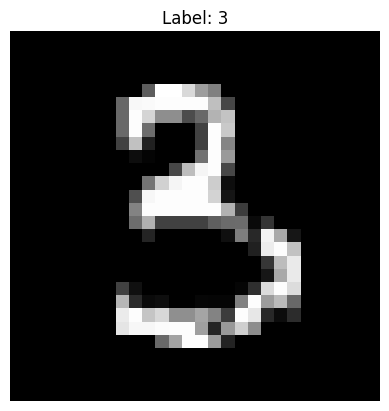

✅ True label: 3
🔮 Model prediction: 0, 7
Net(
  (backbone): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=256, out_features=120, bias=True)
    (8): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
    (2): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [244]:
import matplotlib.pyplot as plt

# Get a batch from trainloader
trainloader, testloader = get_mnist_dataloaders(mnist, batch_size=32)
batch = next(iter(trainloader))
images, labels = batch["image"], batch["label"]  # for HuggingFace dataset

# Convert tensor to NumPy (for matplotlib)
img = images[0].squeeze().numpy()  # (1, 28, 28) -> (28, 28)

# Show the image
plt.imshow(img, cmap="gray")
plt.title(f"Label: {labels[0]}")
plt.axis("off")
plt.show()



# Define model and device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net(num_classes=10).to(device)
model2 = Net2(num_classes=10).to(device)

# Set to eval mode
model.eval()

# Move image to the same device
image = images[0].unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(image)
    predicted_label = output.argmax(dim=1).item()
    output2 = model2(image)
    predicted_label2 = output2.argmax(dim=1).item()

print(f"✅ True label: {labels[0]}")
print(f"🔮 Model prediction: {predicted_label}, {predicted_label2}")

print(model)

In [245]:
def train(net, trainloader, optimizer, device="cpu"):
    """Train the network on the training set."""
    criterion = torch.nn.CrossEntropyLoss()
    net.to(device)
    net.train()
    for batch in trainloader:
        images, labels = batch["image"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        loss = criterion(net(images), labels)
        loss.backward()
        optimizer.step()


def test(net, testloader, device):
    """Validate the network on the entire test set."""
    criterion = torch.nn.CrossEntropyLoss()
    correct, loss = 0, 0.0
    net.to(device)
    net.eval()
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["image"].to(device), batch["label"].to(device)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    accuracy = correct / len(testloader.dataset)
    return loss, accuracy

def run_centralised(
    trainloader, testloader, epochs: int, lr: float, momentum: float = 0.9
):
    """A minimal (but complete) training loop"""

    # instantiate the model
    model = Net(num_classes=10)

    # Discover device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # define optimiser with hyperparameters supplied
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    # train for the specified number of epochs
    for e in range(epochs):
        print(f"Training epoch {e} ...")
        train(model, trainloader, optim, device)

    # training is completed, then evaluate model on the test set
    loss, accuracy = test(model, testloader, device)
    print(f"{loss = }")
    print(f"{accuracy = }")



In [246]:
# from torch import optim

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = Net(num_classes=10).to(device)
# optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)
# loss_fn = nn.CrossEntropyLoss()

# # One simple training loop (run for like 3-5 epochs)
# for epoch in range(5):
#     model.train()
#     for batch in trainloader:
#         images = batch["image"]
#         labels = batch["label"]
#         images, labels = images.to(device), labels.to(device)
        
#         optimizer.zero_grad()
#         output = model(images)
#         loss = loss_fn(output, labels)
#         loss.backward()
#         optimizer.step()
#     print(f"Epoch {epoch+1} done ✅")

In [247]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import IidPartitioner
from flwr_datasets.partitioner import DirichletPartitioner
from flwr_datasets.partitioner import PathologicalPartitioner

NUM_PARTITIONS = 100

partitioner = IidPartitioner(num_partitions=NUM_PARTITIONS)
# Let's partition the "train" split of the MNIST dataset
# The MNIST dataset will be downloaded if it hasn't been already
fds = FederatedDataset(dataset="ylecun/mnist", partitioners={"train": partitioner})


# dirichlet_partitioner = DirichletPartitioner(
#     num_partitions=10, alpha=0.2, partition_by="label"
# )
# fds = FederatedDataset(dataset="ylecun/mnist", partitioners={"train":dirichlet_partitioner})


# pathological_partitioner = PathologicalPartitioner(
#     num_partitions=100, partition_by="label", num_classes_per_partition=2
# )
# fds = FederatedDataset(dataset="ylecun/mnist", partitioners={"train":pathological_partitioner})

In [248]:
partition_0 = fds.load_partition(0)
partition_0

Dataset({
    features: ['image', 'label'],
    num_rows: 600
})

In [249]:
import tenseal as ts
import flwr as fl
import random
import numpy as np
poly_modulus_degree= 8192
def get_context():
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=[60, 40, 60]
    )
    context.generate_galois_keys()
    context.global_scale = 2**40
    return context

shared_context = get_context()
server_context = shared_context.serialize(save_secret_key=False)
client_context = shared_context.serialize(save_secret_key=True)

chunk_size = poly_modulus_degree//2
# use_he = False
use_he = True


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For cudnn backend — makes things deterministic 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [250]:

def encrypt_params(params, context, poly_modulus_degree):
    """
    Encrypts model parameters using TenSEAL CKKS vectors.
    
    Args:
        params (List[np.ndarray]): List of model parameters (numpy arrays).
        context (ts.Context): TenSEAL context.
        poly_modulus_degree (int): Used to determine chunk size.

    Returns:
        List[List[ts.CKKSVector]]: Encrypted chunks for each parameter.
    """
    enc_params = []
    chunk_size = poly_modulus_degree // 2

    for p in params:
        flat = p.flatten()
        chunks = torch.split(torch.from_numpy(flat), chunk_size)

        encrypted_chunks = []
        for i, chunk in enumerate(chunks):
            # print(f"Chunk {i + 1}: length = {len(chunk)}")  # 👈 Add this line
            chunk_list = chunk.tolist()
            enc_vec = ts.ckks_vector(context, chunk_list)
            serialized_vec = enc_vec.serialize()
            encrypted_chunks.append(serialized_vec)

        enc_params.append(encrypted_chunks)

    return enc_params


import numpy as np
import tenseal as ts
def decrypt_params(flat_enc_list, context, model, chunk_size):
    decrypted_params = []

    # Filter only backbone layers (those shared globally)
    state_dict_keys = [k for k in model.state_dict().keys() if k.startswith("backbone.")]
    
    idx = 0  # index in flat_enc_list

    for param_idx, key in enumerate(state_dict_keys):
        target_shape = model.state_dict()[key].shape
        param_size = np.prod(target_shape)

        # Determine number of chunks for this parameter
        num_chunks = (param_size + chunk_size - 1) // chunk_size

        # Slice the correct number of encrypted chunks
        enc_chunks = flat_enc_list[idx : idx + num_chunks]
        idx += num_chunks

        decrypted_chunks = []
        for serialized_vec in enc_chunks:
            ckks_vec = ts.ckks_vector_from(context, serialized_vec)
            decrypted_chunks.extend(ckks_vec.decrypt())

        print(f"[DECRYPT] Param {param_idx} ({key}): expected shape={target_shape}, decrypted size={len(decrypted_chunks)}")

        # Trim and reshape
        decrypted_chunks = decrypted_chunks[:param_size]
        decrypted_array = np.array(decrypted_chunks, dtype=np.float32).reshape(target_shape)
        decrypted_params.append(decrypted_array)

    return decrypted_params

In [251]:
from collections import OrderedDict
from typing import Dict, Tuple

import torch 
from flwr.common import NDArrays, Scalar
from flwr.client import NumPyClient
import sys
import time
import os
class FlowerClient(fl.client.NumPyClient):
    set_seed(42)
    def __init__(self, trainloader, valloader,context,cid) -> None:
        super().__init__()

        self.trainloader = trainloader
        self.valloader = valloader
        self.model = Net(num_classes=10)
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.context = context
        self.last_fit_total_time = 0
        self.backbone = self.model.backbone  # shared
        self.head = self.model.head
        self.cid = cid      # personalized
    def fit(self, parameters, config):
        print("==This is fit method==")
        start_total = time.time()
        server_round = config.get("server_round", -1)
        head_path = f"client{self.cid}_head_weights.pt"
        if use_he:
            # === HE mode ===
            if os.path.exists(head_path):
                self.head.load_state_dict(torch.load(head_path))
                print(f"[Client {self.cid}] 🔁 Loaded personalized head from {head_path}")
            else:
                print(f"[Client {self.cid}] ⚠️ No head file found, starting fresh")
            start_decrypt = time.time()
            enc_param_list = [bytes(ndarray) for ndarray in parameters]
            chunked_enc_params = [enc_param_list]
            decrypted_params = decrypt_params(enc_param_list, self.context, self.model, chunk_size)
            end_decrypt = time.time()
            # print("== Decrypted parameter data types ==")
            # for i, param in enumerate(decrypted_params):
            #     print(f"Param {i}: type={type(param)}, dtype={param.dtype}, shape={param.shape}")
            
            # for param_tensor, decrypted_np in zip(self.model.parameters(), decrypted_params):
            #     param_tensor.data = torch.from_numpy(decrypted_np).to(self.device)
            set_backbone_params(self.model, decrypted_params)
           
        else:
            # === Plaintext mode ===
            set_backbone_params(self.model, parameters)
        #  measure on global before training
        loss_global, acc_global = test(self.model, self.valloader, self.device)
        start_train = time.time()
        # optim = torch.optim.SGD(self.head.parameters(), lr=0.01, momentum=0.9, nesterov=True)
        optim = torch.optim.SGD(
        list(self.backbone.parameters()) + list(self.head.parameters()),
     lr=0.01,
    momentum=0.9,
    nesterov=True
                )

        
        train(self.model, self.trainloader, optim, self.device)
        # measure on local model
        loss_personalized, acc_personalized = test(self.model, self.valloader, self.device)
        end_train = time.time()

        # updated_params = [param_tensor.detach().cpu().numpy() for param_tensor in self.model.parameters()]
        for name, val in self.model.state_dict().items():
            if name.startswith("backbone."):
                print(f"[Sending] {name}: {val.shape}")
        updated_params = get_backbone_params(self.model)
        print(f"✅ updated_params: {len(updated_params)} tensors")
        print(f"🔍 backbone params: {len(list(self.backbone.parameters()))}")
        print(f"🔍 head params: {len(list(self.head.parameters()))}")

        if len(updated_params) == len(list(self.backbone.parameters())):
            print("✅ You're sending the backbone.")
        elif len(updated_params) == len(list(self.head.parameters())):
            print("✅ You're sending the head.")
        else:
            print("⚠️ You're sending something else or mixed.")

        if use_he:
            start_encrypt = time.time()
            encrypted_chunks = encrypt_params(updated_params, self.context, poly_modulus_degree)
            encrypted_bytes_list = [chunk for param in encrypted_chunks for chunk in param]
            end_encrypt = time.time()

            sent_bytes = sum(len(chunk) for chunk in encrypted_bytes_list)
            end_total = time.time()
            print("===Bandwidth usage===")
            print("Bandwidth with HE: ", sent_bytes)
            print("===Runtime performance===")
            print(f"⏱️ Decryption time: {end_decrypt - start_decrypt:.3f} s")
            print(f"⏱️ Training time: {end_train - start_train:.3f} s")
            print(f"⏱️ Encryption time: {end_encrypt - start_encrypt:.3f} s")
            print(f"⏱️ Total fit() time: {end_total - start_total:.3f} s")
            self.last_fit_total_time = end_total - start_total
            # Save head weights for the next round
            torch.save(self.head.state_dict(), head_path)
            print(f"[Client {self.cid}] 💾 Saved personalized head to {head_path}")
            
            return encrypted_bytes_list, len(self.trainloader),{
                "fit_total_time": self.last_fit_total_time,
                "bandwidth": sent_bytes,
                "loss on local model": loss_personalized,
                "accuracy on personalized model": acc_personalized,
                "loss on global model before traning": loss_global,
                "accuracy on global model": acc_global
            }
        else:
            sent_bytes = sum(p.nbytes for p in updated_params)
            end_total = time.time()
            print("===Bandwidth usage===")
            print("Bandwidth without HE: ", sent_bytes)
            print("===Runtime performance===")
            print(f"⏱️ Training time: {end_train - start_train:.3f} s")
            print(f"⏱️ Total fit() time: {end_total - start_total:.3f} s")
            self.last_fit_total_time = end_total - start_total

            return get_backbone_params(self.model), len(self.trainloader),{
                "fit_total_time": self.last_fit_total_time,
                "bandwidth": sent_bytes,
            }

    def evaluate(self, parameters: NDArrays, config: Dict[str, Scalar]):
        print("==This is evaluate method==")
        server_round = config.get("server_round", -1) 
        print(f"== Evaluation at Round {server_round} ==")
        start_eval = time.time()

        if use_he:
            flat_enc_params = [bytes(ndarray) for ndarray in parameters]
            received_bytes = sum(len(chunk) for chunk in flat_enc_params)
            decrypted_params = decrypt_params(flat_enc_params, self.context, self.model,chunk_size=poly_modulus_degree // 2)
            set_backbone_params(self.model, decrypted_params)
        else:
            set_backbone_params(self.model, parameters)
            received_bytes = sum(p.nbytes for p in parameters)

        # ✅ Load personalized head
        head_path = f"client{self.cid}_head_weights.pt"
        if os.path.exists(head_path):
            self.head.load_state_dict(torch.load(head_path))
            print(f"[Client {self.cid}] 🔁 Loaded personalized head from {head_path} for evaluation")
        else:
            print(f"[Client {self.cid}] ⚠️ No head file found for evaluation")

        # Evaluate full model
        loss, accuracy = test(self.model, self.valloader, self.device)
        end_eval = time.time()
        print(f"⏱️ Total evaluate() time: {end_eval - start_eval:.3f} s")
        print(f"===Bandwidth usage===")
        print(f"Bandwidth (received): {received_bytes} bytes")

        metrics = {
            "accuracy": float(accuracy),
            "eval_total_time": end_eval - start_eval,
            "bandwidth": received_bytes,
        }

        return float(loss), len(self.valloader), metrics

# # Two auxhiliary functions to set and extract parameters of a model
# def set_params(model, parameters):
#     """Replace model parameters with those passed as `parameters`."""

#     params_dict = zip(model.state_dict().keys(), parameters)
#     state_dict = OrderedDict({k: torch.from_numpy(v) for k, v in params_dict})
#     # now replace the parameters
#     model.load_state_dict(state_dict, strict=True)

# def get_params(model):
#     """Extract model parameters as a list of NumPy arrays."""
#     return [val.cpu().numpy() for _, val in model.state_dict().items()]
# def get_head_params(model):
#     return [val.cpu().numpy() for name, val in model.state_dict().items() if name.startswith("head.")]

# def set_head_params(model, parameters):
#     head_keys = [k for k in model.state_dict().keys() if k.startswith("head.")]
#     if len(parameters) != len(head_keys):
#         raise ValueError(f"Expected {len(head_keys)} head parameters, but got {len(parameters)}.")
#     head_state_dict = OrderedDict()
#     for k, v in zip(head_keys, parameters):
#         head_state_dict[k] = torch.from_numpy(v)
#     model.load_state_dict(head_state_dict, strict=False)


def get_backbone_params(model):
    return [val.cpu().numpy() for name, val in model.state_dict().items() if name.startswith("backbone.")]

def set_backbone_params(model, parameters):
    backbone_state_dict = OrderedDict()
    backbone_keys = [k for k in model.state_dict().keys() if k.startswith("backbone.")]
    for k, v in zip(backbone_keys, parameters):
        backbone_state_dict[k] = torch.from_numpy(v)
    model.load_state_dict(backbone_state_dict, strict=False)  # strict=False because only backbone keys

# # Similarly for the full model parameters if needed
# def get_full_params(model):
#     return [val.cpu().numpy() for _, val in model.state_dict().items()]

# def set_full_params(model, parameters):
#     params_dict = zip(model.state_dict().keys(), parameters)
#     state_dict = OrderedDict({k: torch.from_numpy(v) for k, v in params_dict})
#     model.load_state_dict(state_dict, strict=True)

In [252]:
from flwr.common import Context
from flwr.client import ClientApp
   

def client_fn(context: Context) -> fl.client.Client:
    """Returns a FlowerClient containing its data partition."""

    partition_id = int(context.node_config["partition-id"])
    partition = fds.load_partition(partition_id, "train")
    # partition into train/validation
    partition_train_val = partition.train_test_split(test_size=0.1, seed=42)

    # Let's use the function defined earlier to construct the dataloaders
    # and apply the dataset transformations
    trainloader, testloader = get_mnist_dataloaders(partition_train_val, batch_size=32)
    context = ts.context_from(client_context)
    cid = os.getpid()
    return FlowerClient(trainloader=trainloader, valloader=testloader,context=context,cid = cid).to_client()


# Concstruct the ClientApp passing the client generation function
client_app = ClientApp(client_fn=client_fn)

In [253]:
from typing import List
from flwr.common import Metrics


# Define metric aggregation function
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # Aggregate and return custom metric (weighted average)
    return {"accuracy": sum(accuracies) / sum(examples)}

In [254]:
import flwr as fl
from typing import List, Tuple, Dict, Optional, Union
from flwr.common import EvaluateRes, FitRes, Scalar
from flwr.server.client_proxy import ClientProxy


def ndarrays_to_byteparam(ckks_vectors: list[ts.CKKSVector]) -> fl.common.Parameters:
    """
    Convert a list of CKKSVector to serialized Flower Parameters.
    """
    serialized = [vec.serialize() for vec in ckks_vectors]
    return fl.common.ndarrays_to_parameters(serialized)

class BytesStrategy(fl.server.strategy.FedAvg):
    def __init__(self, context: fl.common.Context, **kwargs):
        super().__init__(**kwargs)
        self.context = context
    
    
    def aggregate_fit(self, server_round, results, failures):
        # print(f"\n[Round {server_round}] Starting encrypted aggregation")
        print("Starting encrypted aggregation")
        
        if failures:
            print(f"⚠️  {len(failures)} client(s) failed.")
            for i, failure in enumerate(failures):
                print(f"  - Failure {i+1}: {repr(failure)}")

        # Step 1: Deserialize all encrypted chunks for all clients
        all_encrypted = []
        for client, fit_res in results:
            client_chunks = []
            for serialized_chunk in fl.common.parameters_to_ndarrays(fit_res.parameters):
                ckks_vec = ts.ckks_vector_from(self.context, bytes(serialized_chunk))
                client_chunks.append(ckks_vec)
            all_encrypted.append(client_chunks)

        if not all_encrypted:
            print("❌ No valid client updates received. Skipping round.")
            return None, {}

        # Step 2: Aggregate corresponding chunks across clients
        num_chunks = len(all_encrypted[0])
        aggregated_chunks = []

        for idx in range(num_chunks):
            chunk_group = [client_chunks[idx] for client_chunks in all_encrypted]
            avg_chunk = chunk_group[0]
            for vec in chunk_group[1:]:
                avg_chunk += vec
            avg_chunk *= 1 / len(chunk_group)
            aggregated_chunks.append(avg_chunk)

        # Step 3: (Optional) Debug decrypted values
        # decrypted_preview = np.array(aggregated_chunks[0].decrypt())
        # print(f"[DEBUG] Sample from decrypted first chunk: {decrypted_preview[:5]}")
        fit_times = []
        for client, fit_res in results:
            fit_time = fit_res.metrics.get("fit_total_time", 0.0)
            fit_times.append(fit_time)

        avg_fit_time = sum(fit_times) / len(fit_times) if fit_times else 0.0
        # Collect personalized loss and accuracy from each client
        losses = [fit_res.metrics.get("loss on local model", 0.0) for _, fit_res in results]
        accuracies = [fit_res.metrics.get("accuracy on personalized model", 0.0) for _, fit_res in results]

        # Calculate averages (you can also do weighted average if you want, using client data size)
        avg_loss = sum(losses) / len(losses) if losses else 0.0
        avg_accuracy = sum(accuracies) / len(accuracies) if accuracies else 0.0

        print(f"⏱️ Round {server_round} average personalized loss: {avg_loss:.4f}")
        print(f"⏱️ Round {server_round} average personalized accuracy: {avg_accuracy:.4f}")

        print(f"⏱️ Round {server_round} average fit time: {avg_fit_time:.3f} s")

        # Step 4: Return aggregated result as Flower Parameters
        new_params = ndarrays_to_byteparam(aggregated_chunks)
        serialized = vec.serialize()
        # print("[SERVER DEBUG] First 100 bytes of chunk 0:", serialized[:100])

        return new_params,  {
        "fit_total_time": avg_fit_time,
        "loss value on personalized model": avg_loss,
        "avg_accuracy on personalized model": avg_accuracy
    }
    
    def configure_evaluate(
        self,
        server_round: int,
        parameters: fl.common.Parameters,
        client_manager: fl.server.client_manager.ClientManager,
    ) -> List[Tuple[fl.server.client_proxy.ClientProxy, fl.common.EvaluateIns]]:
        
        # ✅ Call the parent method to get the client instructions
        client_instructions = super().configure_evaluate(server_round, parameters, client_manager)

        # ✅ Inject server_round into config
        updated_instructions = []
        for client, evaluate_ins in client_instructions:
            new_config = dict(evaluate_ins.config)
            new_config["server_round"] = server_round  # 👈 Add round here
            updated_ins = fl.common.EvaluateIns(evaluate_ins.parameters, new_config)
            updated_instructions.append((client, updated_ins))

        return updated_instructions
    
    def aggregate_evaluate(
        self,
        server_round: int,
        results: List[Tuple[ClientProxy, EvaluateRes]],
        failures: List[Union[Tuple[ClientProxy, FitRes], BaseException]],
    ) -> Tuple[Optional[float], Dict[str, Scalar]]:

        if not results:
            return None, {}
        # print(f"[DEBUG] Received {len(results)} evaluation results")
        # for i, (_, r) in enumerate(results):
        #     print(f"[DEBUG][Client {i}] Metrics: {r.metrics}")
        # Base loss/metrics
        aggregated_loss, _ = super().aggregate_evaluate(server_round, results, failures)

        # Collect values
        examples = [r.num_examples for _, r in results]
        total_examples = sum(examples)

        accuracies = [r.metrics["accuracy"] * r.num_examples for _, r in results]
        # print("Fit times: ", fit_times)
        # print("Accuracies: ", accuracies)
        eval_times = [r.metrics.get("eval_total_time", 0.0) for _, r in results]
        bandwidths = [r.metrics.get("bandwidth", 0.0) for _, r in results]

        # Aggregate
        aggregated_accuracy = sum(accuracies) / total_examples
        # Avoid ZeroDivisionError by checking length
        # avg_fit_time = sum(fit_times) / len(fit_times) if fit_times else 0.0
        avg_eval_time = sum(eval_times) / len(eval_times) if eval_times else 0.0
        avg_bandwidth = sum(bandwidths) / len(bandwidths) if bandwidths else 0.0

      

        return float(aggregated_loss), {
            "accuracy": float(aggregated_accuracy),
            "eval_total_time": avg_eval_time,
            "bandwidth": avg_bandwidth,
        }

In [255]:
from flwr.common import ndarrays_to_parameters
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
import random

num_rounds = 10

def server_fn(context: Context):
    set_seed(42)
    model = Net(num_classes=10)
    print(list(model.state_dict().keys()))
    plain_params = get_backbone_params(model)

    if use_he:
        ckks_chunks = encrypt_params(plain_params, shared_context, poly_modulus_degree)
        flat_encrypted = [chunk for param in ckks_chunks for chunk in param]
        global_model_init = ndarrays_to_parameters(flat_encrypted)

        strategy = BytesStrategy(
            context=shared_context,
            fraction_fit=1,
            fraction_evaluate=1,
            initial_parameters=global_model_init,
            evaluate_metrics_aggregation_fn=weighted_average,
        )
    else:
        global_model_init = ndarrays_to_parameters(plain_params)

        strategy = FedAvg(
            fraction_fit=1,
            fraction_evaluate=1,
            initial_parameters=global_model_init,
            evaluate_metrics_aggregation_fn=weighted_average,
        )

    config = ServerConfig(num_rounds=num_rounds)
    return ServerAppComponents(strategy=strategy, config=config)

# Create your ServerApp
server_app = ServerApp(server_fn=server_fn)

In [256]:
from flwr.simulation import run_simulation

num_clients = 10
run_simulation(
    server_app=server_app, client_app=client_app, num_supernodes=num_clients, backend_config={"num_cpus": 1},
)

INFO :      Starting Flower ServerApp, config: num_rounds=10, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


['backbone.0.weight', 'backbone.0.bias', 'backbone.3.weight', 'backbone.3.bias', 'backbone.7.weight', 'backbone.7.bias', 'head.0.weight', 'head.0.bias', 'head.2.weight', 'head.2.bias']


(raylet) /Users/creamy/Research/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
(raylet)   warnings.warn(


(ClientAppActor pid=5020) ==This is fit method==
(ClientAppActor pid=5020) [Client 5020] ⚠️ No head file found, starting fresh
(ClientAppActor pid=5020) [DECRYPT] Param 0 (backbone.0.weight): expected shape=torch.Size([6, 1, 5, 5]), decrypted size=150
(ClientAppActor pid=5020) [DECRYPT] Param 1 (backbone.0.bias): expected shape=torch.Size([6]), decrypted size=6
(ClientAppActor pid=5020) [DECRYPT] Param 2 (backbone.3.weight): expected shape=torch.Size([16, 6, 5, 5]), decrypted size=2400
(ClientAppActor pid=5020) [DECRYPT] Param 3 (backbone.3.bias): expected shape=torch.Size([16]), decrypted size=16
(ClientAppActor pid=5020) [DECRYPT] Param 4 (backbone.7.weight): expected shape=torch.Size([120, 256]), decrypted size=30720
(ClientAppActor pid=5020) [DECRYPT] Param 5 (backbone.7.bias): expected shape=torch.Size([120]), decrypted size=120
(ClientAppActor pid=5020) [Sending] backbone.0.weight: torch.Size([6, 1, 5, 5])
(ClientAppActor pid=5020) [Sending] backbone.0.bias: torch.Size([6])
(Clie

INFO :      aggregate_fit: received 10 results and 0 failures
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


...

INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)
INFO :      aggregate_fit: received 10 results and 0 failures
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Starting encrypted aggregation
⏱️ Round 10 average personalized loss: 0.5358
⏱️ Round 10 average personalized accuracy: 0.9267
⏱️ Round 10 average fit time: 0.215 s
(ClientAppActor pid=5018) ==This is fit method== [repeated 30x across cluster]
(ClientAppActor pid=5020) [DECRYPT] Param 5 (backbone.7.bias): expected shape=torch.Size([120]), decrypted size=120 [repeated 366x across cluster]
(ClientAppActor pid=5018) [Sending] backbone.7.bias: torch.Size([120]) [repeated 180x across cluster]
(ClientAppActor pid=5018) ✅ updated_params: 6 tensors [repeated 30x across cluster]
(ClientAppActor pid=5018) 🔍 backbone params: 6 [repeated 30x across cluster]
(ClientAppActor pid=5018) 🔍 head params: 4 [repeated 30x across cluster]
(ClientAppActor pid=5018) ✅ You're sending the backbone. [repeated 30x across cluster]
(ClientAppActor pid=5020) ===Bandwidth usage=== [repeated 64x across cluster]
(ClientAppActor pid=5018) Bandwidth with HE:  3059863 [repeated 30x across cluster]
(ClientAppActor pid=5018

INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 21.84s
INFO :      	History (loss, distributed):
INFO :      		round 1: 4.556234502792359
INFO :      		round 2: 4.382760906219483
INFO :      		round 3: 2.987123191356659
INFO :      		round 4: 1.5086281836032867
INFO :      		round 5: 1.0131488472223282
INFO :      		round 6: 0.8079505860805511
INFO :      		round 7: 0.6235620811581611
INFO :      		round 8: 0.5599249616265297
INFO :      		round 9: 0.47880143001675607
INFO :      		round 10: 0.41148354560136796
INFO :      	History (metrics, distributed, fit):
INFO :      	{'avg_accuracy on personalized model': [(1, 0.1583333333333333),
INFO :      	                                        (2, 0.30833333333333335),
INFO :      	                                        (3, 0.5416666666666667),
INFO :      	                                        (4, 0.71),
INFO :      	                           

(ClientAppActor pid=5018) [Client 5018] 🔁 Loaded personalized head from client5018_head_weights.pt [repeated 30x across cluster]
(ClientAppActor pid=5018) ==This is evaluate method== [repeated 30x across cluster]
(ClientAppActor pid=5018) == Evaluation at Round 10 == [repeated 30x across cluster]
(ClientAppActor pid=5018) [Client 5018] 🔁 Loaded personalized head from client5018_head_weights.pt for evaluation [repeated 30x across cluster]
(ClientAppActor pid=5018) ⏱️ Total evaluate() time: 0.015 s [repeated 30x across cluster]
(ClientAppActor pid=5018) Bandwidth (received): 1705818 bytes [repeated 30x across cluster]
(ClientAppActor pid=5018) [DECRYPT] Param 5 (backbone.7.bias): expected shape=torch.Size([120]), decrypted size=120 [repeated 54x across cluster]
(ClientAppActor pid=5018) ===Bandwidth usage=== [repeated 5x across cluster]


(raylet) /Users/creamy/Research/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020 [repeated 7x across cluster]
(raylet)   warnings.warn( [repeated 7x across cluster]
